In [1]:
# ============================================================
# WEEK 3 - DAY 1: LTV REGRESSION MODEL
# Project: Customer Churn Prediction & Lifetime Value Engine
# ============================================================
# Objective:
# Is notebook mein hum active customers ke expected
# lifetime revenue ko predict karne ke liye regression
# model develop karna start karenge.
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np

# Display basic information clearly
print("Libraries imported successfully.")
print("Starting Week 3 - Day 1: LTV Regression Model")

Libraries imported successfully.
Starting Week 3 - Day 1: LTV Regression Model


In [3]:
# ============================================================
# STEP 2: LOAD ENGINEERED DATASET
# ============================================================
# Day 1 mein hum Week 2 ke feature-engineering output ko use
# karenge, taaki LTV model directly engineered features par
# develop kiya ja sake.
# ============================================================

# Load the engineered dataset
df = pd.read_csv("../data/initial_engineered_customer_dataset.csv")

# Display dataset dimensions for verification
print("Engineered dataset loaded successfully.")
print("Dataset shape:", df.shape)

# Display first 5 rows to verify the data
df.head()

Engineered dataset loaded successfully.
Dataset shape: (7043, 36)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,HasInternetService,HasOnlineSecurity,HasOnlineBackup,HasDeviceProtection,HasTechSupport,HasStreamingTV,HasStreamingMovies,IsPaperlessBilling,IsAutoPayment,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,0,1,0,0,0,0,1,0,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1,1,0,1,0,0,0,0,0,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,1,1,0,0,0,0,1,0,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1,1,0,1,1,0,0,0,1,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,0,0,0,0,0,0,1,0,2


In [4]:
# Check dataset columns and data types
# Isse verify hoga ki engineered dataset ke 36 columns
# sahi data types ke saath load hue hain.

print("Dataset Information")
print("===================")

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nColumn Data Types:")
print(df.dtypes)

Dataset Information
Total rows: 7043
Total columns: 36

Column Data Types:
customerID                 str
gender                     str
SeniorCitizen            int64
Partner                    str
Dependents                 str
tenure                   int64
PhoneService               str
MultipleLines              str
InternetService            str
OnlineSecurity             str
OnlineBackup               str
DeviceProtection           str
TechSupport                str
StreamingTV                str
StreamingMovies            str
Contract                   str
PaperlessBilling           str
PaymentMethod              str
MonthlyCharges         float64
TotalCharges               str
Churn                      str
IsSeniorCitizen          int64
HasPartner               int64
HasDependents            int64
HasFamily                int64
HasPhoneService          int64
HasInternetService       int64
HasOnlineSecurity        int64
HasOnlineBackup          int64
HasDeviceProtection      i

In [5]:
# Check missing values in the engineered dataset
# Isse pata chalega ki kisi column me NULL/missing values hain ya nahi.

print("Missing Values Check")
print("====================")

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing Values Check
Series([], dtype: int64)

Total missing values: 0


In [6]:
# Check for duplicate customers
# CustomerID unique hona chahiye.
# Isse verify hoga ki same customer multiple times present nahi hai.

duplicate_count = df["customerID"].duplicated().sum()

print("Duplicate Customer Check")
print("========================")
print("Duplicate customer IDs:", duplicate_count)

Duplicate Customer Check
Duplicate customer IDs: 0


In [7]:
# Check the target variable distribution
# Isse pata chalega ki kitne customers churn hue aur kitne nahi hue.

print("Churn Distribution")
print("==================")

churn_counts = df["Churn"].value_counts()

print(churn_counts)

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [8]:
# Generate statistical summary for numerical features
# Isse mean, standard deviation, minimum, maximum etc. verify honge.

print("Numerical Features Summary")
print("==========================")

numeric_summary = df.describe()

print(numeric_summary)

Numerical Features Summary
       SeniorCitizen       tenure  MonthlyCharges  IsSeniorCitizen  \
count    7043.000000  7043.000000     7043.000000      7043.000000   
mean        0.162147    32.371149       64.761692         0.162147   
std         0.368612    24.559481       30.090047         0.368612   
min         0.000000     0.000000       18.250000         0.000000   
25%         0.000000     9.000000       35.500000         0.000000   
50%         0.000000    29.000000       70.350000         0.000000   
75%         0.000000    55.000000       89.850000         0.000000   
max         1.000000    72.000000      118.750000         1.000000   

        HasPartner  HasDependents    HasFamily  HasPhoneService  \
count  7043.000000    7043.000000  7043.000000      7043.000000   
mean      0.483033       0.299588     0.534289         0.903166   
std       0.499748       0.458110     0.498858         0.295752   
min       0.000000       0.000000     0.000000         0.000000   
25%    

In [9]:
# Check TotalCharges data type
# LTV regression ke liye TotalCharges numeric hona zaroori hai.

print("TotalCharges Data Type Check")
print("============================")

print("Data type:", df["TotalCharges"].dtype)

print("\nNon-numeric values:")
print(pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum())

TotalCharges Data Type Check
Data type: str

Non-numeric values:
11


In [10]:
# Identify the non-numeric TotalCharges values
# Pehle exact problematic values dekh rahe hain
# taaki cleaning safely ki ja sake.

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Non-numeric TotalCharges values:")
print(df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "TotalCharges"]])

Non-numeric TotalCharges values:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [11]:
# Clean and convert TotalCharges into numeric format
# Blank/space values are treated as 0 because these customers have tenure = 0.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

# Fill the 11 missing TotalCharges values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges Data Type After Cleaning:")
print(df["TotalCharges"].dtype)

print("\nRemaining Missing TotalCharges:")
print(df["TotalCharges"].isna().sum())

TotalCharges Data Type After Cleaning:
float64

Remaining Missing TotalCharges:
0


In [12]:
# Check categorical columns and their unique values
# This helps us understand which text-based features need encoding
# before building the LTV regression model.

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(list(categorical_columns))

print("\nUnique Values in Each Categorical Column:")
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Unique Values in Each Categorical Column:

customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype

C:\Users\himan\AppData\Local\Temp\ipykernel_11068\3499729215.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [13]:
# Remove CustomerID because it is only a unique identifier
# and does not provide meaningful information for LTV prediction.

df_model = df.drop(columns=["customerID"]).copy()

print("CustomerID removed successfully.")
print("Original dataset shape:", df.shape)
print("Model dataset shape:", df_model.shape)

CustomerID removed successfully.
Original dataset shape: (7043, 36)
Model dataset shape: (7043, 35)


In [14]:
# Define target variable and predictor features
# TotalCharges is the target variable for LTV regression.
# All remaining columns will be used as input features.

X = df_model.drop(columns=["TotalCharges"]).copy()
y = df_model["TotalCharges"].copy()

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nTarget variable:")
print("TotalCharges")

print("\nTarget data type:")
print(y.dtype)

Features (X) shape: (7043, 34)
Target (y) shape: (7043,)

Target variable:
TotalCharges

Target data type:
float64


In [15]:
# Split the dataset into training and testing sets.
# Training data will be used to build the LTV regression model.
# Testing data will be used to evaluate the model on unseen customers.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed")
print("==========================")
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Train-Test Split Completed
Training features: (5634, 34)
Testing features : (1409, 34)
Training target  : (5634,)
Testing target   : (1409,)


In [16]:
# Encode categorical features using One-Hot Encoding.
# The encoder is fitted only on training data to avoid data leakage.
# The same transformation is then applied to the testing data.

from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

# Create One-Hot Encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit encoder on training data and transform training data
X_train_encoded = encoder.fit_transform(X_train[categorical_features])

# Transform testing data using the same fitted encoder
X_test_encoded = encoder.transform(X_test[categorical_features])

print("\nCategorical encoding completed.")
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

C:\Users\himan\AppData\Local\Temp\ipykernel_11068\3895823894.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Categorical encoding completed.
Encoded training shape: (5634, 43)
Encoded testing shape : (1409, 43)


In [17]:
# Combine numerical and encoded categorical features
# This creates the final feature matrix for the LTV regression model.

# Identify numerical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

# Extract numerical features
X_train_numerical = X_train[numerical_features].values
X_test_numerical = X_test[numerical_features].values

# Combine numerical + encoded categorical features
X_train_final = np.hstack([X_train_numerical, X_train_encoded])
X_test_final = np.hstack([X_test_numerical, X_test_encoded])

print("\nFinal feature preparation completed.")
print("Final training feature shape:", X_train_final.shape)
print("Final testing feature shape :", X_test_final.shape)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'IsSeniorCitizen', 'HasPartner', 'HasDependents', 'HasFamily', 'HasPhoneService', 'HasInternetService', 'HasOnlineSecurity', 'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupport', 'HasStreamingTV', 'HasStreamingMovies', 'IsPaperlessBilling', 'IsAutoPayment', 'TotalServices']

Final feature preparation completed.
Final training feature shape: (5634, 61)
Final testing feature shape : (1409, 61)


In [18]:
# Train the LTV regression model
# Random Forest Regression is used as the first baseline model.

from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_ltv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model using the prepared training data
rf_ltv_model.fit(X_train_final, y_train)

print("LTV Random Forest model trained successfully.")

LTV Random Forest model trained successfully.


In [19]:
# Generate LTV predictions on the test dataset
# The trained model will predict the expected TotalCharges (LTV)
# for customers in the testing dataset.

y_pred = rf_ltv_model.predict(X_test_final)

print("LTV predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("First 10 predicted LTV values:")
print(y_pred[:10])

LTV predictions generated successfully.
Number of predictions: 1409
First 10 predicted LTV values:
[  24.71375 1025.5455  1053.73825   76.311   3353.615   6201.541
 1709.126   5104.624   7315.882     19.41   ]


In [20]:
# Evaluate the LTV regression model
# We compare actual TotalCharges with predicted LTV values.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display model performance
print("LTV Regression Model Evaluation")
print("===============================")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

LTV Regression Model Evaluation
MAE : 53.3
RMSE: 80.48
R²  : 0.9988


In [21]:
# Compare actual and predicted LTV values
# This helps verify how closely the model predictions match the actual values.

comparison = pd.DataFrame({
    "Actual_LTV": y_test.values,
    "Predicted_LTV": y_pred
})

print("Actual vs Predicted LTV")
print("======================")
print(comparison.head(10))

Actual vs Predicted LTV
   Actual_LTV  Predicted_LTV
0       24.80       24.71375
1      996.45     1025.54550
2     1031.70     1053.73825
3       76.35       76.31100
4     3260.10     3353.61500
5     6127.60     6201.54100
6     1759.40     1709.12600
7     5016.65     5104.62400
8     7250.15     7315.88200
9       19.40       19.41000


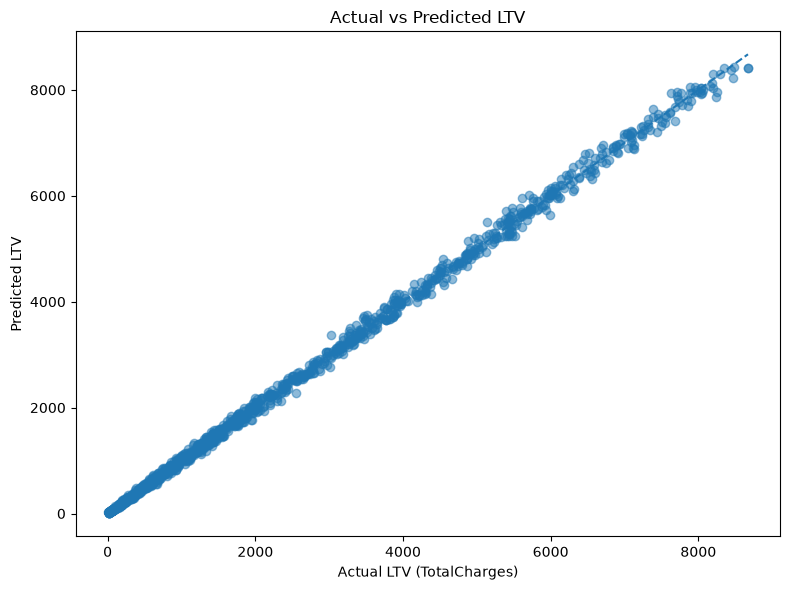

In [22]:
# Visualize Actual vs Predicted LTV
# Points close to the diagonal line indicate similar actual and predicted values.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual LTV (TotalCharges)")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV")

plt.tight_layout()
plt.show()

In [23]:
# Save the trained LTV model
# This allows the trained model to be reused later without retraining.

import joblib
import os

# Make sure the models directory exists
os.makedirs("../models", exist_ok=True)

# Save the trained Random Forest model
model_path = "../models/ltv_random_forest_model.pkl"
joblib.dump(rf_ltv_model, model_path)

print("LTV Random Forest model saved successfully.")
print("Model saved at:", model_path)

LTV Random Forest model saved successfully.
Model saved at: ../models/ltv_random_forest_model.pkl
